**Fatigue State Extension**

This part of the model looks to understand the influence fatigue has on decision making, this was done by using the elapsed time of each quarter in the 2022-23 pbp dataset as a proxy for determining fatigue for players

**Import required libraries and read dataset**

In [ ]:
# import required libraries for analysis
! pip install nashpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nashpy as nash

# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/2022-23 play-by-play.csv')

# read 2022-23 play-by-play dataset
df = pd.read_csv('2022-23 play-by-play.csv')

**Define the fatigue proxy**

In [ ]:
# convert elapsed column from string to total seconds
df['elapsed'] = pd.to_timedelta(df['elapsed']).dt.total_seconds()
# sort events by game and elapsed time to ensure correct order
df = df.sort_values(['game_id', 'elapsed']).reset_index(drop=True)

# define the fatigue proxy
def fatigue_proxy(row):
  period = row['period']
  elapsed = row['elapsed']
  # skip events with no time data
  if pd.isna(period) or pd.isna(elapsed):
    return None
  # compute the amount of seconds elapsed since start of game
  true_elapsed = (period - 1) * 720 + elapsed

  # split each period of the game and label a fatigue state

  # 720 seconds or less is equal to the first 12 minutes of a basketball
  # quarter (Q1)
  if true_elapsed < 720:
    return 'Early Fatigue'

  # if elapsed time is between 720 and 1740 seconds this is equal to quarters
  # 2 and 3 where players may expierence slight fatigue
  elif true_elapsed < 1740:
    return 'Slight Fatigue'

  # if not Q1, Q2 or Q3 then this will be classed as heavy fatigue (late stage)
  else:
    return 'Heavy Fatigue'

# apply the fatigue proxy function
df['fatigue'] = df.apply(fatigue_proxy, axis=1)

# print distribution
print('Fatigue by Quarter/Period')
print(df['fatigue'].value_counts())
print()
print('Percentages')
print(df['fatigue'].value_counts(normalize=True).round(3) * 100)

Fatigue by Quarter/Period
fatigue
Heavy Fatigue     95447
Slight Fatigue    79262
Early Fatigue     54053
Name: count, dtype: int64

Percentages
fatigue
Heavy Fatigue     41.7
Slight Fatigue    34.6
Early Fatigue     23.6
Name: proportion, dtype: float64


**Get 3PT% by contest level and fatigue state**

In [ ]:
# create function for defensive pressure
def defensive_pressure(row):
  # get coordinates of shot location
  x = row.get('converted_x')
  y = row.get('converted_y')

  # define defensive pressure based on shot location
  if pd.isna(x) or pd.isna(y):
    return 'Unknown'

  if x > 40 and abs(y) > 20:
    return 'Sag Off'

  elif x > 30 and abs(y) < 15:
    return 'Hard-Close Out'

  return 'Moderate Contest'

# filter 3PT shots and gather the 'made' shots
shooting_fatigue = df[(df['event_type'] == 'shot') &
 (df['shot_distance'] >=22) & (df['fatigue'].notna())].copy()
shooting_fatigue['made'] = (shooting_fatigue['result'] == 'made').astype(int)

# remove rows with missing coordinates to avoid data issues
shooting_fatigue = shooting_fatigue[
    shooting_fatigue['converted_x'].notna() &
    shooting_fatigue['converted_y'].notna()
]

# compute 3PT% for each fatigue state and contest type
shooting_fatigue['contest'] = shooting_fatigue.apply(defensive_pressure, axis=1)
shooting_fatigue_defence = shooting_fatigue.groupby(['fatigue', 'contest'])['made'].mean()

# print distribution
print()
print("3PT% by fatigue and contest level")
print()
print(shooting_fatigue_defence.round(3))


3PT% by fatigue and contest level

fatigue         contest         
Early Fatigue   Hard-Close Out      0.411
                Moderate Contest    0.371
                Sag Off             0.391
Heavy Fatigue   Hard-Close Out      0.372
                Moderate Contest    0.336
                Sag Off             0.340
Slight Fatigue  Hard-Close Out      0.368
                Moderate Contest    0.359
                Sag Off             0.372
Name: made, dtype: float64


**Get action frequencies for each fatigue state**

In [ ]:
shot_mask = df['event_type'] == 'shot'

df['action'] = None
# create a mask to identify where event is shot
df.loc[shot_mask & (df['shot_distance'] >= 22), 'action'] = 'Shoot'
# create a mask to identify where event is drive
df.loc[shot_mask & (df['shot_distance'] < 10), 'action'] = 'Drive'

# only use rows with an action (Drive or Shoot) and a fatigue state
fatigue_frequency = df[df['action'].notna() & df['fatigue'].notna()]

# get % per fatigue state
empirical_fatigue = fatigue_frequency.groupby(['fatigue', 'action']).size(
).unstack(
    fill_value=0)
empirical_fatigue_percentage = empirical_fatigue.div(empirical_fatigue
                                                     .sum(axis=1),
                                                     axis=0) * 100

# print distribution
print()
print("Action frequencies per fatigue state")
print()
print(empirical_fatigue_percentage.round(2))


Action frequencies per fatigue state

action          Drive  Shoot
fatigue                     
Early Fatigue   52.77  47.23
Heavy Fatigue   52.27  47.73
Slight Fatigue  52.86  47.14


**Compute mean 3PT% for each fatigue state**

In [ ]:
# league average 3PT%
baseline_3pt = 0.362

"""
compute mean 3PT% for each fatigue state used to derive shoot_fatigue
% adjustment in payoff matrix function
"""
fatigue_shooting_means = shooting_fatigue.groupby('fatigue')['made'].mean()
print('Mean 3PT% per fatigue state')
print()
print(fatigue_shooting_means)

Mean 3PT% per fatigue state

fatigue
Early Fatigue     0.377498
Heavy Fatigue     0.339337
Slight Fatigue    0.362344
Name: made, dtype: float64


**Recompute payoff matrix for each fatigue state**

In [ ]:
# function to recompute the payoff matrix per fatigue state
def fatigue_payoff_matrix(fatigue_state, contest_stats):
    # defensive contest actions
    contests = ['Hard-Close Out', 'Moderate Contest', 'Sag Off']
    # default 3PT%
    defaults = [0.362, 0.342, 0.352]

    # get empirical 3PT% else fall back to defaults when data is unavailable
    if fatigue_state in contest_stats.index.get_level_values(0):
        variables = (
            contest_stats.loc[fatigue_state]
            .reindex(contests).fillna(dict(zip(contests, defaults)))
            .to_numpy()
        )
    else:
        variables = np.array(defaults)

    # create fatigue adjustment for both drive and shooting actions
    shoot_fatigue = fatigue_shooting_means.get(fatigue_state, baseline_3pt) - baseline_3pt
    drive_fatigue = shoot_fatigue * 0.5

    # baseline model statistics
    baseline_drive = 0.701
    free_throw_drive = 1.562
    free_throw_shoot = 2.343
    pass_points = 1.142
    foul_rate = 0.133
    turnover = 0.141

    # shoot payoff
    shoot = (variables + shoot_fatigue) * 3 + foul_rate * free_throw_shoot

    # drive payoff
    drive_mods = np.array([0.05, 0.00, -0.05])
    drive = (
        (baseline_drive + drive_mods + drive_fatigue)
        * 2 * (1 - turnover)
        + (foul_rate * free_throw_drive)
    )

    # create payoff matrix
    return np.vstack([
        shoot,
        drive,
    ])

fatigue_states = ['Early Fatigue', 'Slight Fatigue', 'Heavy Fatigue']
fatigue_matrices = {} # store payoff matrix
fatigue_equilibria = {} # store equilibria

# print recomputed matrix
print("Fatigue payoff Matrices")

for state in fatigue_states:
    fatigue_matrices[state] = fatigue_payoff_matrix(
        state, shooting_fatigue_defence)
    print(f"\n{state} Payoff Matrix:")
    print(fatigue_matrices[state].round(3))

Fatigue payoff Matrices

Early Fatigue Payoff Matrix:
[[1.591 1.472 1.532]
 [1.511 1.425 1.339]]

Slight Fatigue Payoff Matrix:
[[1.417 1.39  1.429]
 [1.498 1.412 1.326]]

Heavy Fatigue Payoff Matrix:
[[1.359 1.252 1.265]
 [1.478 1.393 1.307]]


**Solve for Nash Equilibrium**

In [ ]:
for state in fatigue_states:
  # create a game using payoff matrix
  game = nash.Game(fatigue_matrices[state], -fatigue_matrices[state])

  # solve for Nash equilibrium by using support enumeration
  equilibrium = list(game.support_enumeration())

  # compute equilibrium and print results

  if equilibrium:
    offence, defence = equilibrium[0]
    fatigue_equilibria[state] = {
        'offence': offence,
        'defence': defence
        }

    print(f"\n{state}")
    print(f"Shoot {round(offence[0]*100, 2)}%")
    print(f"Drive {round(offence[1]*100, 2)}%")


Early Fatigue
Shoot 100.0%
Drive 0.0%

Slight Fatigue
Shoot 68.68%
Drive 31.32%

Heavy Fatigue
Shoot 0.0%
Drive 100.0%


**Visualisations to compare models for results writing**

In [ ]:
"""
this section of the notebook creates a comparison table between the baseline
and empirical model to be able to visualise the shooting and drive % for each
fatigue state
"""

# create a list to be able to store the results
fatigue_comparison = []

for state in fatigue_states:
  # fetch the equilibrium probabilites
  baseline = fatigue_equilibria.get(state, {}).get('offence', [np.nan, np.nan])
  # fetch empirical frequencies
  empirical = empirical_fatigue_percentage.loc[state] if state in empirical_fatigue_percentage.index else pd.Series()

  # add the statistics to the results list defined earlier
  fatigue_comparison.append([
      state,
      baseline[0] * 100,
      empirical.get('Shoot', 0),
      baseline[1] * 100,
      empirical.get('Drive', 0),
      baseline[0] * 100 - empirical.get('Shoot', 0)
  ])

# create the comparisn table
comparison_df = pd.DataFrame(
    fatigue_comparison,
    columns=[
        'Fatigue_State',
        'Baseline_Shoot%',
        'Empirical_Shoot%',
        'Baseline_Drive%',
        'Empirical_Drive%',
        'Difference'
    ]
).round(2)

# print comparison table
print("Model Comparison")
print()
print(comparison_df)

Model Comparison

    Fatigue_State  Baseline_Shoot%  Empirical_Shoot%  Baseline_Drive%  \
0   Early Fatigue           100.00             47.23             0.00   
1  Slight Fatigue            68.68             47.14            31.32   
2   Heavy Fatigue             0.00             47.73           100.00   

   Empirical_Drive%  Difference  
0             52.77       52.77  
1             52.86       21.53  
2             52.27      -47.73  


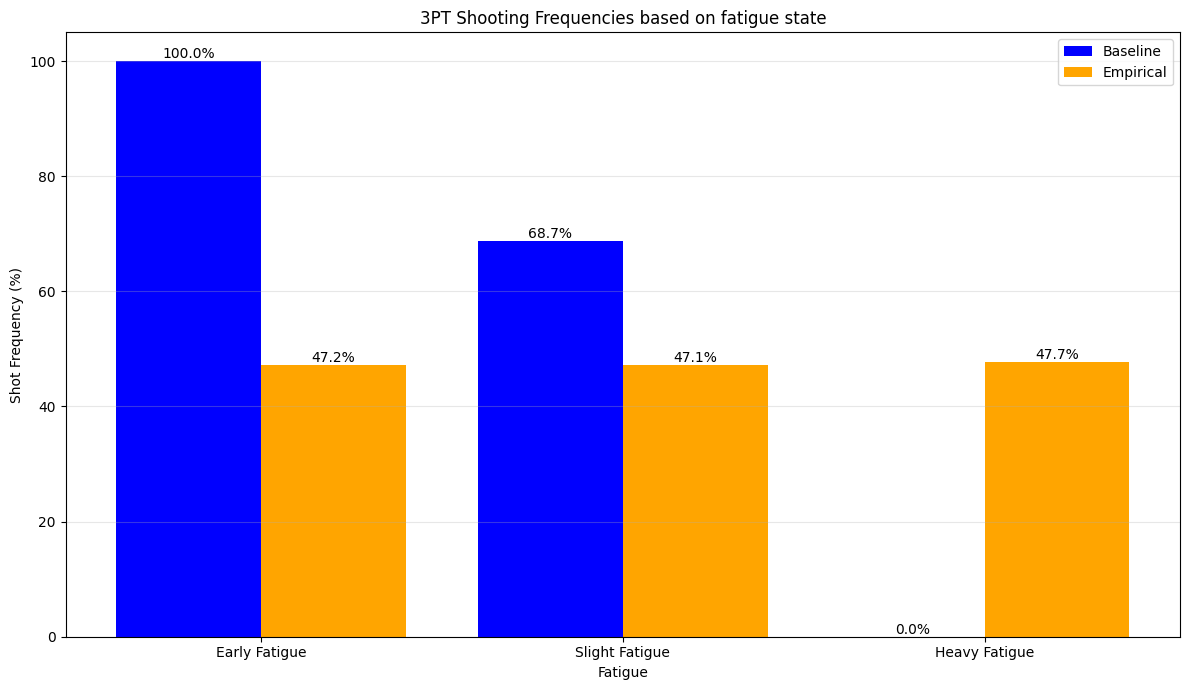

In [ ]:
"""
create a visualisation graph to show the frequencies of both shoot and drive
for each clock segment
"""

# extract baseline and empirical frequencies
baseline_shooting = [fatigue_equilibria[s]['offence'][0] * 100 for s in fatigue_states]
empirical_shooting = [empirical_fatigue_percentage.loc[s].get('Shoot', 0)
                     if s in empirical_fatigue_percentage.index else 0
                     for s in fatigue_states]

# create graph
fig, br = plt.subplots(figsize=(12,7))

# label x axis as clock segments
x = np.arange(len(fatigue_states))

width = 0.40

# plot baseline bar
br.bar(x - 0.2, baseline_shooting, width, label='Baseline', color='blue')
# plot empirical bar
br.bar(x + 0.2, empirical_shooting, width, label='Empirical', color='orange')

# plot graph details
br.set_xticks(x)
br.set_ylabel('Shot Frequency (%)')
br.set_xlabel('Fatigue')
br.set_xticklabels(fatigue_states)
br.set_title('3PT Shooting Frequencies based on fatigue state')
br.legend()
br.grid(axis='y', alpha=0.3)

# add % labels on the bars
for bars in br.containers:
  br.bar_label(bars, fmt='%.1f%%')

# show graph output
plt.tight_layout()
plt.show()